## Computational Homework 1, 2026

#### Due September 9

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import sympy

# Make readable plots
plt.rcParams.update({'font.size':16, 'axes.labelsize':16})

Unless expressly stated otherwise, please make sure your plot axes have labels and multiple lines on the same plot are explained in a legend.

#### Brachistochrone problem

Here you will make a two-panel figure showing position and velocity along the cycloid curve discussed in Chapter 6, Example 2 of your textbook. The cycloid is the solution to the brachistochrone problem.

<ol>
    <li>In the top panel of your figure, plot one downward loop of the cycloid. Put one end of the curve at the origin of your coordinate system. Mark both axes in units of $a$, the radius of the wheel that would create your cycloid if rolled on the underside of the $x$-axis.</li>
    <li>Assume a small, frictionless block slides down the cycloid starting at rest from the origin. In your figure's bottom panel, plot the velocity of the block as a function of the $x$-coordinate. Make sure both plots share the same $x$-axis.</li>
</ol>

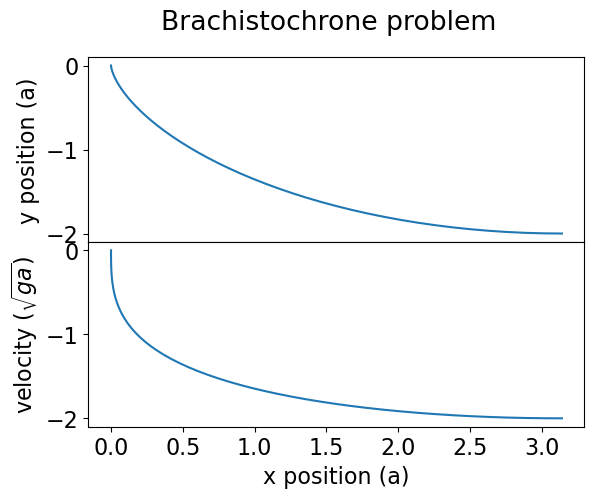

In [11]:
# Your code here

fig, ax  = plt.subplots(2, sharex=True)  #make fig with two subplots 
fig.subplots_adjust(hspace=0) #removes horizontal space between axes

t_array = np.linspace(0, np.pi)
x_array = t_array - np.sin(t_array)
y_array = np.ones_like(t_array) - np.cos(t_array)
v_array = (2*y_array)**0.5

ax[0].plot(x_array, -y_array)
ax[1].plot(x_array, -v_array)

#labels
ax[0].set_ylabel('y position (a)')
ax[1].set_ylabel(r'velocity ($\sqrt{ga}$)')
ax[1].set_xlabel('x position (a)')
fig.suptitle('Brachistochrone problem')

plt.show()



#### Symbolic math with [<tt>SymPy</tt>](https://docs.sympy.org/latest/index.html)

<ol start=3>
    <li>Use <tt>SymPy</tt> to find the path $y(x)$ for which the integral 
    $\int_{x_1}^{x^2} x \sqrt{1 - y^{\prime}(x)^2} \: dx$ is stationary.</li>
</ol>

$\int_{x_1}^{x^2} x \sqrt{1 - y^{\prime}(x)^2} \: dx$

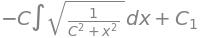

In [ ]:
# Your code here
from sympy import *
init_printing(use_unicode=True)

x = symbols('x')
C = symbols('C', real = True, constant = True)
y = Function('y')(x)

functional = x * (1 - y.diff(x) **2)**0.5

df_dyp = functional.diff(y.diff())

result = dsolve(df_dyp - C)



#### Learning to figure skate

Olympic figure skaters used to be judged on how well they could carve attractive shapes into the ice. Coaches of novice skaters would etch guide circles into the ice using a special compass, which consisted of a horizontal rod with a pivot at one end and a sharp point attached to the underside of the rod near the other end. (Note: The ice compass is similar to the rotating rod described in Taylor problem 7.21, except the pivot is at the end of the rod instead of the center.)

<ol start=4</ol>
<li>Assume a bead slides freely along the rod with negligible friction. Place the pivot at the origin and let $r(t)$ represent the bead's distance from the pivot. Plot $r(t)$ for a bead that is near the origin at $t = 0$, when the rod starts to rotate with constant angular speed $\omega$.</li>
</ol>

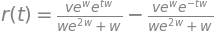

In [14]:
# Your code here

#solve for r(t)
t, w, m, v= symbols('t w m v')
r = Function('r')(t)

lagrange = 0.5 * m * (r.diff(t)**2 + r**2 * w**2)
eqns = euler_equations(lagrange, r, t)
solution = dsolve(eqns[0], r, ics = {r.subs(t,0): 0, r.diff().subs(t, 1): v})
solution


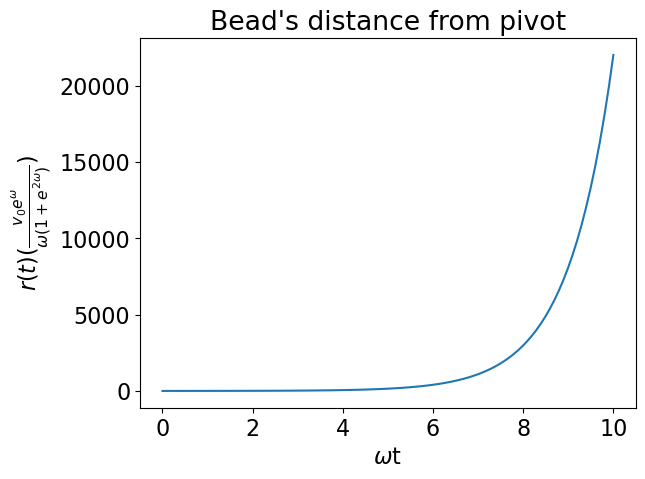

In [54]:
tw = np.linspace(0, 10, 100)
r = np.exp(tw) - np.exp(-tw)

plt.figure()

plt.plot(tw, r)

plt.xlabel(r'$\omega$t')
plt.ylabel(r'$r(t) (\frac{v_0e^\omega}{\omega(1+e^{2\omega})})$')
plt.title("Bead's distance from pivot")

plt.show()

#### Helical wire

A smooth wire is bent into the shape of a helix, with cylindrical polar coordinates $\rho = R$ and $z = \lambda \phi$, where $R$ and $\lambda$ are constants and the $z$ axis is oriented vertically upward. Gravity points in the $-z$ direction. (This setup is similar to the children's toy with beads on bent wires described in class.)

<ol start=5>
    <li>Use <tt>matplotlib</tt> to draw a cartoon representing the shape and orientation of the wire. Put $(\hat{x}, \hat{z})$ unit vectors on your cartoon. You may turn of the plot axes if you wish.</li>
    <li>Plot the bead's acceleration in the vertical direction, $\ddot{z}(z)$.</li>
</ol>

$\ddot{z}(z)$

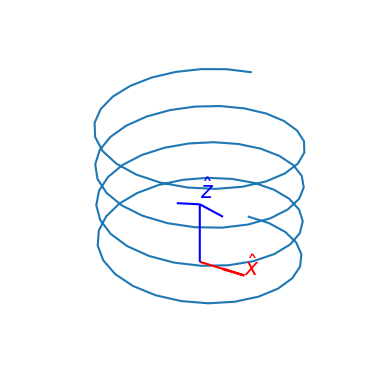

Text(0.5, 0.98, 'Vertical acceleration of bead travelling down helix')

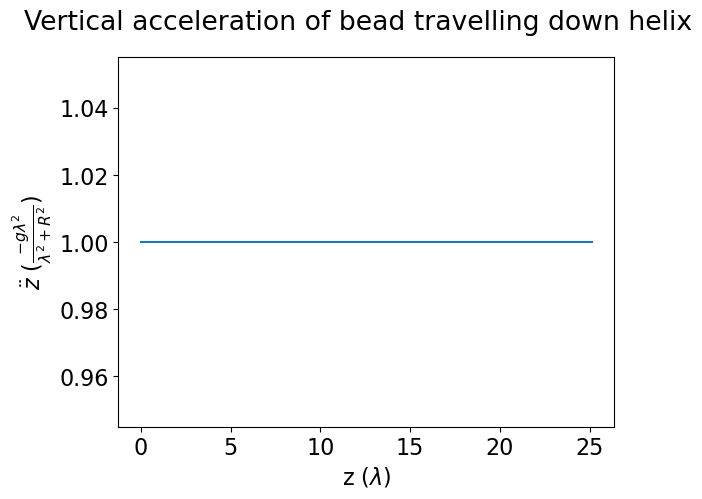

In [68]:
# Your code here

ax = plt.figure().add_subplot(projection='3d')

theta = np.linspace(0, 8 * np.pi, 100)
z = theta 
rho = 1
x = rho * np.sin(theta)
y = rho * np.cos(theta)

ax.plot(x, y, z) #plot cartoon

#plot unit vectors

i0, j0, k0 = [0,0,0], [0,0,0], [0,0,0]
i, j, k = [1, 0, 0], [0, 1, 0], [0, 0, 10]
ax.quiver(i0, j0, k0, i0, j0, k, color=['r', 'g', 'b'], arrow_length_ratio=0.1)
ax.quiver(i0, j0, k0, i, j0, k0, color=['r', 'g', 'b'], length = 0.5, arrow_length_ratio=0.5)

ax.text(x = 0, y = 0, z = 11, color = 'b', s = r'$\hat{z}$')
ax.text(x = 0.5, y = 0, z = 0, color = 'r', s = r'$\hat{x}$')

ax.axis('off')
plt.show()

#plot bead's acceleration in vertical direction

#solve for bead's vertical acceleration
t, m, g, l, u = symbols('t m g l u')
p = Function('p')(t)

lagrange = 0.5 * m * (u**2 * p.diff(t)**2 + l** 2 * p.diff(t)**2) - m*g*l*p #substitute l*phi for z
eqns = euler_equations(lagrange, p, t)
phidotdot = solve(eqns[0], p.diff(t, 2))
zdotdot = phidotdot[0] * l
zdotdot #zdotdot is a constant

fig, ax = plt.subplots()
ax.plot(z, np.ones_like(z)) 

#labels
ax.set_ylabel(r'$\ddot{z}\ (\frac{-g\lambda^2}{\lambda^2 + R ^2})$')
ax.set_xlabel(r'z ($\lambda$)')
fig.suptitle("Vertical acceleration of bead travelling down helix")

In [70]:
#scratch work

from sympy import *
#x, y, z = symbols('x y z')
init_printing(use_unicode=True)
#f = symbols('f', cls=Function) #define a function for our functional

#df_dyprime = diff(x * (1 - y**2)**0.5, y)
#print(diff(x * (1 - y**2)**0.5, y))
#-1.0*x*y/(1 - y**2)**0.5
#solve(-1.0*x*y/(1 - y**2)**0.5, y, dict=True)
#solve(x**2 - y, x, dict=True)

'''x, y = symbols('x y')

y = Function('y')(x)
yp = y.diff(x)
eq = x * (1 - yp**2)**0.5
euler_lagrange = eq.diff(yp)
print(euler_lagrange)'''


'''yp = Derivative(y, x)
functional = x * (1 - yp**2)**0.5
df_dyprime = Derivative(functional, Derivative(y, x))
df_dyprime'''

x = symbols('x')
y = Function('y')(x)

functional = (1 + y.diff(x)**2)**0.5
eqns = euler_equations(functional)
eqns
solution = dsolve(eqns[0], y)
solution


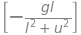

In [ ]:
t, m, g, l, u = symbols('t m g l u')
r = Function('r')(t)
p = Function('p')(t)
z = Function('z')(t)

lagrange = 0.5 * m * (u**2 * p.diff(t)**2 + l** 2 * p.diff(t)**2) - m*g*l*p
eqns = euler_equations(lagrange, p, t)
phidotdot = solve(eqns[0], p.diff(t, 2))
#zdotdot = phidotdot[0] * l
#zdotdot_scaled = zdotdot / 
#solution = dsolve(eqns[0], z)
phidotdot

In [ ]:
from sympy import *
init_printing(use_unicode=True)

x = symbols('x')
y = Function('y')(x)

functional = x * (1 - y.diff(x) **2)**0.5

eqns = euler_equations(functional)
eqns_simple = simplify(eqns[0])
eqns_simple
solution = dsolve(eqns_simple, y)
#solution